<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi

</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 5</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 5</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Aufgabe 05_01**
- Aufgabe 05_02
- Aufgabe 05_03

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Singulärwertzerlegung 05_01</td>



In der Vorlesung haben Sie die **Singulärwertzerlegung** von Matrizen kennengelernt. Dabei wird eine beliebige Matrix $M$ als das Produkt dreier spezieller Matrizen dargestellt:
$$
M=U\Sigma V^\dagger
$$
wobei $\Sigma$ eine Diagonalmatrix ist, deren Einträge gerade die Singulärwerte von $M$ sind. Je größer der einzelne Singulärwert ist, desto wichtiger ist sein Beitrag zur Berechnung von $M$. Daraus folgt, dass die Matrix $M$ durch eine Matrix $\tilde{M}^{(n)}$ approximiert werden kann:

$$
\tilde{M}^{(n)} = U\tilde{\Sigma}^{(n)}V^\dagger
$$ 

wobei die Matrix $\tilde{\Sigma}^{(n)}$ nur die $n$ größten Singulärwerte enthält und alle anderen auf Null gesetzt werden.


Die Singulärwertzerlegung ist ein unschätzbares Werkzeug für den Umgang mit großen höherdimensionalen Daten.  In vielen Fällen tragen, bei Daten in hohen Dimensionen, die meisten Dimensionen nicht zur Struktur der Daten bei. Diese herauszufiltern erfordert jedoch eine gewisse Sorgfalt, da möglicherweise nicht klar ist, welche davon wichtig sind, wenn die Wichtigkeit aus einer Kombination von Dimensionen stammen könnte. Die Singulärwertzerlegung kann als eine Möglichkeit angesehen werden, diese wichtigen Dimensionen und damit die Schlüsselbeziehungen in den Daten zu finden.

Diese Tatsache wollen wir nun für die **Bildkomprimierung** ausnutzen. Der Einfachheit halber betrachten wir ein Graustufenbild, so dass wir die Graustufen des Bildes als eine Matrix mit Elementen zwischen 0 und 1 interpretieren können.
Wir bilden nun zunächst die Singulärwertzerlegung, behalten die $n$ größten Singulärwerte und verwerfen die restlichen Werte wie oben beschrieben. Nun wollen wir untersuchen, wie viel Bildinformation in diesen ersten $n$ Singularwerten kodiert ist und das Bild durch Berechnung der $\tilde{M}^{(n)}$ rekonstruieren. 
Zusammen mit den Übungsaufgaben finden Sie diesmal auch Bilder im .png-Format. Importieren Sie diese Bilder in die folgende Zelle und führen Sie die Singulärwertzerlegung durch. Wie viele Singulärwerte werden benötigt, um Albert Einstein zu erkennen? Spielen Sie auch mit anderen Bildern und finden Sie heraus, wie viele Singulärwerte Sie brauchen, um das Bild einigermaßen gut erkennen zu können. Hängt es von der Art des Bildes ab?

*Hinweise:*

- Führen Sie die Singulärwertzerlegung mit der von Julia bereitgestellten Funktion `svd` durch, die über das Paket `LinearAlgebra` nutzbar ist.
- Um die Anzahl der verwendeten Eigenwerte zu reduzieren, können Sie die von `svd` kommenden Matrizen einfach schrumpfen.
- Sie können die Bilder mit der Funktion `load` einlesen, diese Funktion liefert direkt eine Matrix von Pixeldaten welche Sie direkt in `svd` verwenden können. 

---

Nach dem laden eines Bildes mit `load` ist der zurückgegebene Wert vom Typ `Matrix{Gray{...}}`. Um daraus eine `Float` Matrix zu erstellen müssen Sie einfach ein `Float64.(...)` benutzen, bsp:

```
img = load(...)
img_fl = Float64.(img)
```

Andersherum, wenn Sie eine `Matrix{Float64}` haben, wie nach Anwenden der `svd` auf die Bilddatei, und diese als Bilddatei darstellen wollen, müssen Sie `Gray.(...)` benutzen, bsp:

```
Gray.(img_fl)
```

---

## Singulärwertzerlegung von Bilddaten

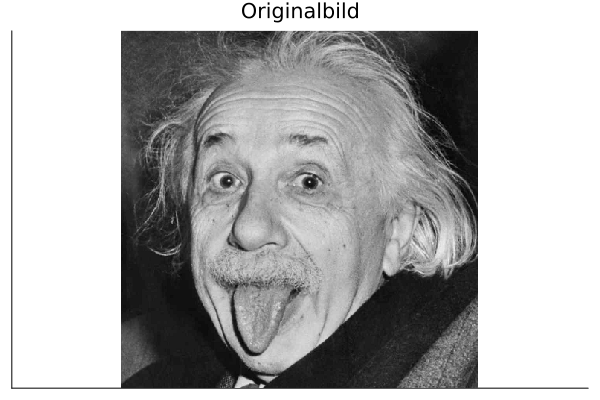

In [50]:

using LinearAlgebra
using Plots, Images

img = load("einstein.png")
img = Gray.(img)
plot(img, axis=nothing)
title!("Originalbild")

In [51]:




function Bild(k)
    img_fl = Float64.(img)
    U, sigma, V = svd(img)
    for i in k:length(sigma)
        sigma[i]=0
    end
    sigma = Diagonal(sigma)

    A= U * sigma * V'
    return Gray.(A)
end



Bild (generic function with 1 method)

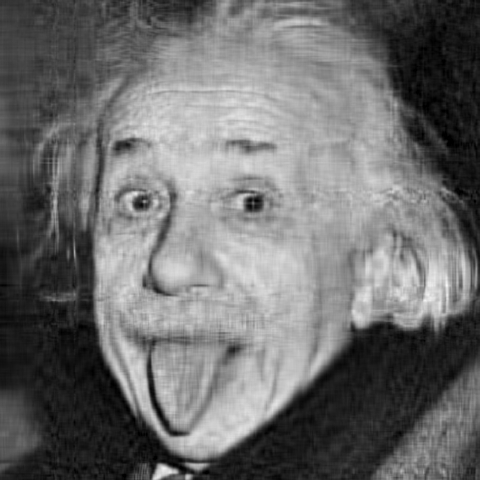

In [52]:
Bild(30)

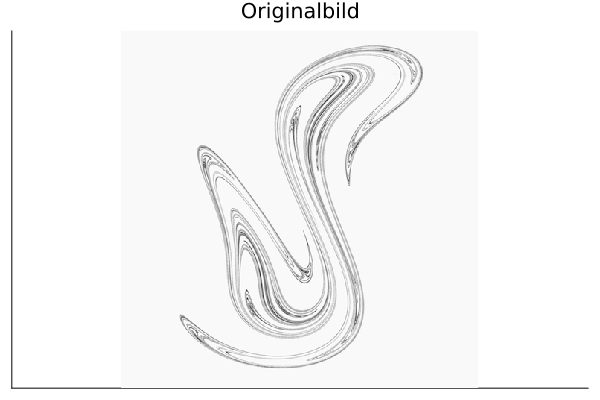

In [46]:
img = load("Duffing.png")
img = Gray.(img)
plot(img, axis=nothing)
title!("Originalbild")

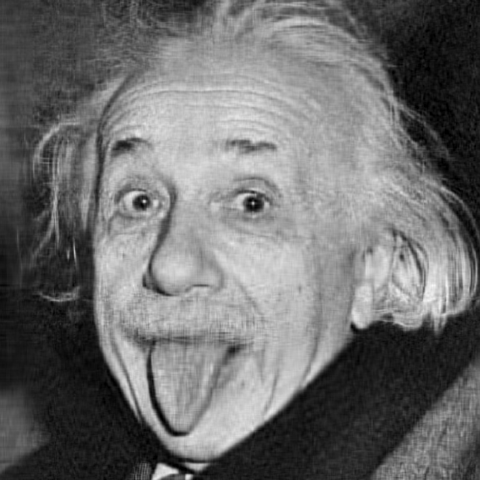

In [53]:
Bild(50)

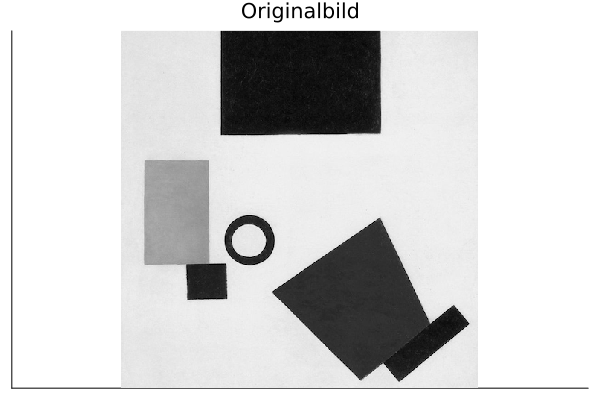

In [54]:
img = load("Malewitsch.png")
img = Gray.(img)
plot(img, axis=nothing)
title!("Originalbild")

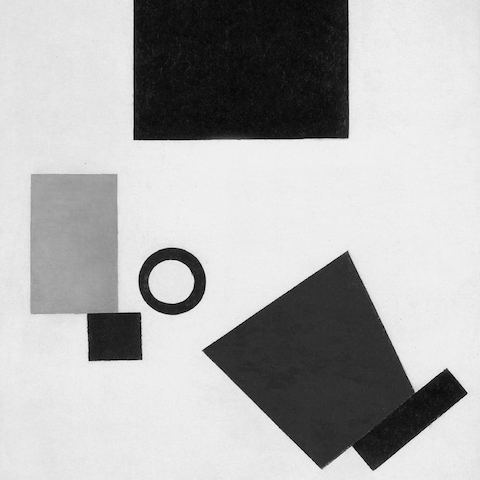

In [55]:
Bild(300)